In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

from sklearn.metrics import accuracy_score, confusion_matrix

import seaborn as sns

import os
import pickle
import shap
from matplotlib.ticker import LogLocator, NullLocator
from matplotlib.colors import LogNorm

/home/rdube/ML/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Import data

In [2]:
suffix = ''

cwd = os.getcwd() + '/'

charged_bdt_true = np.load(cwd + 'charged_bdt_true' + suffix + '.npy')
charged_bdt_pred = np.load(cwd + 'charged_bdt_pred' + suffix + '.npy')

neutral_bdt_true = np.load(cwd + 'neutral_bdt_true' + suffix + '.npy')
neutral_bdt_pred = np.load(cwd + 'neutral_bdt_pred' + suffix + '.npy')




#with open(cwd + 'shapley_values_df' + suffix + '.pkl', 'rb') as f:
#    df_list = pickle.load(f)

# Figure 4 - bdt PID on charged particles

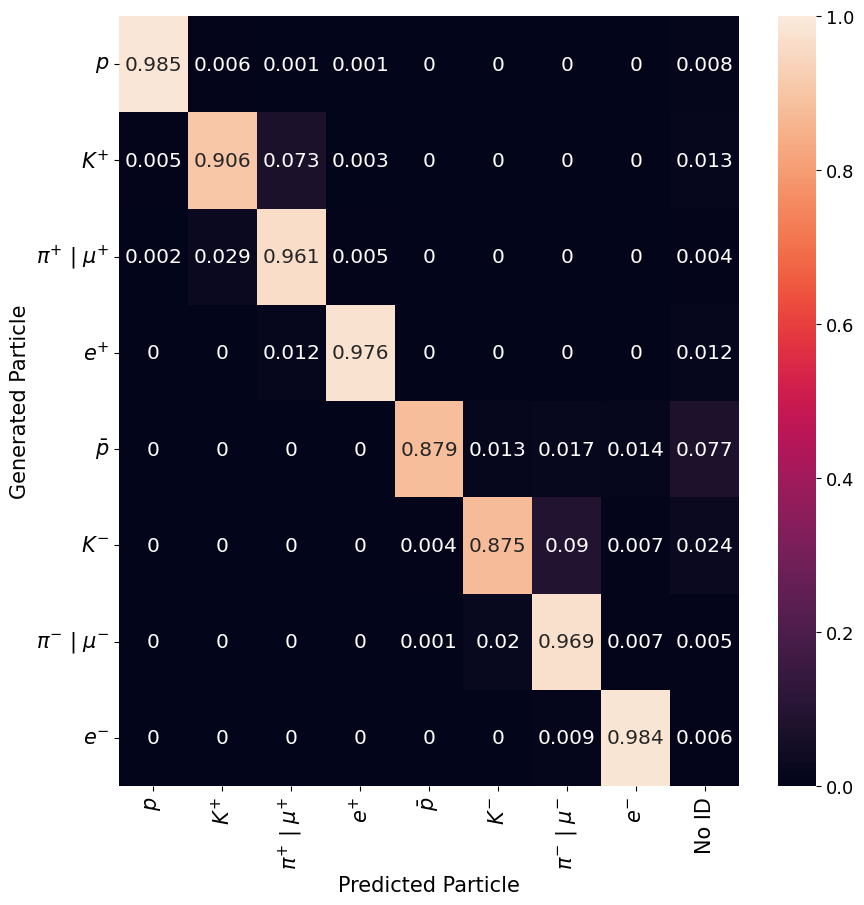

In [3]:
acc = accuracy_score(charged_bdt_true, charged_bdt_pred)

cm = confusion_matrix(charged_bdt_true, charged_bdt_pred, normalize='true')
#cm = np.array([cm[i]/len(testy[testy == i]) for i in range(len(cm))])
cm = np.round(cm, decimals=3)
cm = cm[:8]
fig = plt.figure()
fig.set_size_inches(10, 10)
ax = fig.add_subplot(111)


heatmap = sns.heatmap(cm, annot=True, fmt='g', ax=ax, vmin=0, vmax=1, annot_kws={"size": 14.5})

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)

ax.set_xlabel('Predicted Particle', fontsize=15);ax.set_ylabel('Generated Particle', fontsize=15); 
#ax.set_title(f'Charged Particles PID with Total Accuracy of {round(acc, 4)}', fontsize=17); 
ax.xaxis.set_ticklabels([r'$p$', r'$K^{+}$', r'$\pi^{+}$ | $\mu^{+}$', r'$e^{+}$', r'$\bar{p}$', r'$K^{-}$', r'$\pi^{-}$ | $\mu^{-}$', r'$e^{-}$','No ID'], fontsize=15, rotation='vertical');
ax.yaxis.set_ticklabels([r'$p$', r'$K^{+}$', r'$\pi^{+}$ | $\mu^{+}$', r'$e^{+}$', r'$\bar{p}$', r'$K^{-}$', r'$\pi^{-}$ | $\mu^{-}$', r'$e^{-}$'], fontsize=15, rotation='horizontal');

# Figure 5 - bdt PID for neutral particles

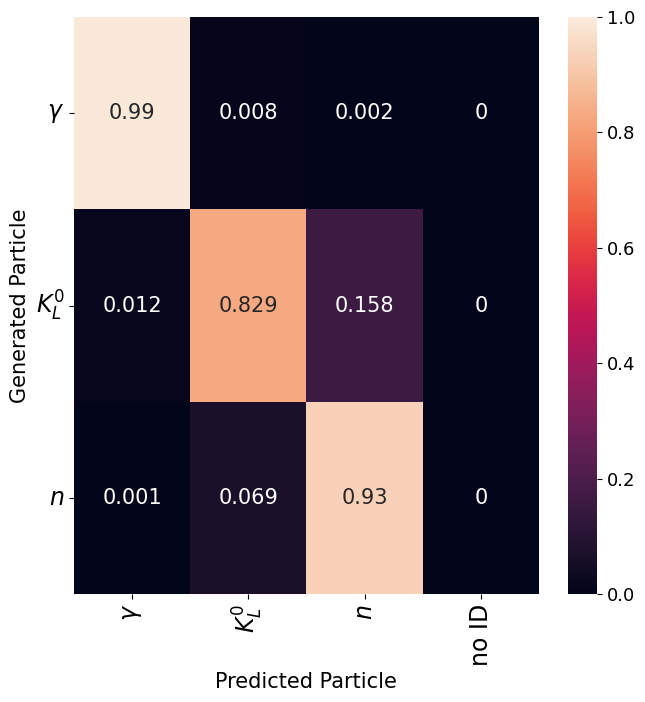

In [4]:
acc_new = accuracy_score(neutral_bdt_true, neutral_bdt_pred)

cm = confusion_matrix(neutral_bdt_true, neutral_bdt_pred, normalize='true')
cm = np.round(cm, decimals=3)
cm = cm[:-1, :]

fig = plt.figure()
fig.set_size_inches(7.5, 7.5)
ax = fig.add_subplot(111)


heatmap = sns.heatmap(cm, annot=True, fmt='g', ax=ax, vmin=0, vmax=1, annot_kws={"fontsize": 15});

cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=13)

ax.set_xlabel('Predicted Particle', fontsize=15);ax.set_ylabel('Generated Particle', fontsize=15); 
#ax.set_title(f'Total Accuracy of {round(acc_new, 4)}', fontsize=17); 
ax.xaxis.set_ticklabels([r'$\gamma$', r'$K_{L}^{0}$', r'$n$', 'no ID'], fontsize=17, rotation='vertical');
ax.yaxis.set_ticklabels([r'$\gamma$', r'$K_{L}^{0}$', r'$n$'], fontsize=17, rotation='horizontal');

# Figure 6 - Shapley Vaues for positively charged particles

In [ ]:
fig, ax = plt.subplots(figsize=(25, 8))

ptypedic_new = {0:r'$\gamma$', 1:r'$K_{L}^{0}$', 2:r'$n$', 3:r'$p$', 4:r'$\bar{p}$', 
            5:r'$K^{+}$', 6:r'$K^{-}$', 7:r'$e^{-}$', 8:r'$e^{+}$', 
            9:r'$\pi^{+}$ | $\mu^{+}$', 10:r'$\pi^{-}$ | $\mu^{-}$'}

box_width = 0.2
#box_pos = 0.2
cap_width = 2
whisker_width = 2
color_dict = {0:'violet', 1:'red', 2:'skyblue', 3:'green'}
pos_dict = {0:-0.25, 1:-0.25 + (1*0.1666), 2:-0.25 + (2*0.1666), 3:-0.25 + (3*0.1666)}
count = 0

pos_char = np.array([3, 5, 8, 9])

for i in pos_char:
    box = df_list[i].boxplot(boxprops=dict(edgecolor='k', alpha=1, facecolor=color_dict[count]),
                          positions=np.arange(len(np.array(df_list[i].columns))) + pos_dict[count],
                          capprops=dict(color=color_dict[count], linewidth=cap_width),
                          flierprops=dict(marker='.', markerfacecolor=color_dict[count], markersize=8, markeredgecolor=color_dict[count]),
                          whiskerprops=dict(color=color_dict[count], linewidth=whisker_width),
                          medianprops=dict(color='k', linewidth=2.5),
                          showfliers=False,
                          widths=box_width,
                          patch_artist=True)
    plt.scatter(0, 0, c=color_dict[count], label=ptypedic_new[i], marker='s')
    count += 1

char_labs = np.array(df_list[i].columns)

ax.set_xticks(np.arange(len(char_labs)))
ax.set_xticklabels(char_labs)
plt.yscale('log')

ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('')
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_ylabel('SHAP Value Magnitude', fontsize=20, labelpad=20, rotation=90)
plt.setp(box.xaxis.get_majorticklabels(), fontsize=15)
plt.xticks(rotation=90, fontsize=20)


y_locator = LogLocator(base=10.0, numticks=15)
y_minor_locator = NullLocator()
plt.gca().yaxis.set_major_locator(y_locator)
plt.gca().yaxis.set_minor_locator(y_locator)
plt.grid(True, which="both", axis="y")
plt.yticks(rotation=90, fontsize=15)

legend = ax.legend(fontsize = 15, loc = 'lower right')

# Rotate the legend text
for text in legend.get_texts():
    text.set_rotation(90)

plt.show()

# Figure 7 - Shapley values for negatively charged particles

In [ ]:
fig, ax = plt.subplots(figsize=(25, 8))

ptypedic_new = {0:r'$\gamma$', 1:r'$K_{L}^{0}$', 2:r'$n$', 3:r'$p$', 4:r'$\bar{p}$', 
            5:r'$K^{+}$', 6:r'$K^{-}$', 7:r'$e^{-}$', 8:r'$e^{+}$', 
            9:r'$\pi^{+}$ | $\mu^{+}$', 10:r'$\pi^{-}$ | $\mu^{-}$'}


box_width = 0.2
#box_pos = 0.2
cap_width = 2
whisker_width = 2
color_dict = {0:'violet', 1:'red', 2:'skyblue', 3:'green'}
pos_dict = {0:-0.25, 1:-0.25 + (1*0.1666), 2:-0.25 + (2*0.1666), 3:-0.25 + (3*0.1666)}
count = 0

pos_char = np.array([4, 6, 7, 10])

for i in pos_char:
    box = df_list[i].boxplot(boxprops=dict(edgecolor='k', alpha=1, facecolor=color_dict[count]),
                          positions=np.arange(len(np.array(df_list[i].columns))) + pos_dict[count],
                          capprops=dict(color=color_dict[count], linewidth=cap_width),
                          flierprops=dict(marker='.', markerfacecolor=color_dict[count], markersize=8, markeredgecolor=color_dict[count]),
                          whiskerprops=dict(color=color_dict[count], linewidth=whisker_width),
                          medianprops=dict(color='k', linewidth=2.5),
                          showfliers=False,
                          widths=box_width,
                          patch_artist=True)
    plt.scatter(0, 0, c=color_dict[count], label=ptypedic_new[i], marker='s')
    count += 1

char_labs = np.array(df_list[i].columns)

ax.set_xticks(np.arange(len(char_labs)))
ax.set_xticklabels(char_labs)
plt.yscale('log')

ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('')
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_ylabel('SHAP Value Magnitude', fontsize=20, labelpad=20, rotation=90)
plt.setp(box.xaxis.get_majorticklabels(), fontsize=15)
plt.xticks(rotation=90, fontsize=20)


y_locator = LogLocator(base=10.0, numticks=15)
y_minor_locator = NullLocator()
plt.gca().yaxis.set_major_locator(y_locator)
plt.gca().yaxis.set_minor_locator(y_locator)
plt.grid(True, which="both", axis="y")
plt.yticks(rotation=90, fontsize=15)

legend = ax.legend(fontsize = 15, loc = 'lower right')

# Rotate the legend text
for text in legend.get_texts():
    text.set_rotation(90)

plt.show()

# Figure 8 - Shapley Values for neutral particles

In [ ]:
fig, ax = plt.subplots(figsize=(12.5, 8))

ptypedic_new = {0:r'$\gamma$', 1:r'$K_{L}^{0}$', 2:r'$n$', 3:r'$p$', 4:r'$\bar{p}$', 
            5:r'$K^{+}$', 6:r'$K^{-}$', 7:r'$e^{-}$', 8:r'$e^{+}$', 
            9:r'$\pi^{+}$ | $\mu^{+}$', 10:r'$\pi^{-}$ | $\mu^{-}$'}

box_width = 0.2
#box_pos = 0.2
cap_width = 2
whisker_width = 2
color_dict = {0:'violet', 1:'red', 2:'skyblue'}
pos_dict = {0:-0.25, 1:0, 2:0.25}
count = 0

pos_char = np.array([0, 1, 2])

for i in pos_char:
    box = df_list[i].boxplot(boxprops=dict(edgecolor='k', alpha=1, facecolor=color_dict[count]),
                          positions=np.arange(len(np.array(df_list[i].columns))) + pos_dict[count],
                          capprops=dict(color=color_dict[count], linewidth=cap_width),
                          flierprops=dict(marker='.', markerfacecolor=color_dict[count], markersize=8, markeredgecolor=color_dict[count]),
                          whiskerprops=dict(color=color_dict[count], linewidth=whisker_width),
                          medianprops=dict(color='k', linewidth=2.5),
                          showfliers=False,
                          widths=box_width,
                          patch_artist=True)
    plt.scatter(0, 0, c=color_dict[count], label=ptypedic_new[i], marker='s')
    count += 1

char_labs = np.array(df_list[i].columns)

ax.set_xticks(np.arange(len(char_labs)))
ax.set_xticklabels(char_labs)
plt.yscale('log')

ax.tick_params(axis='y', labelsize=15)
ax.set_ylabel('')
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.set_ylabel('SHAP Value Magnitude', fontsize=20, labelpad=20, rotation=90)
plt.setp(box.xaxis.get_majorticklabels(), fontsize=15)
plt.xticks(rotation=90, fontsize=20)


y_locator = LogLocator(base=10.0, numticks=15)
y_minor_locator = NullLocator()
plt.gca().yaxis.set_major_locator(y_locator)
plt.gca().yaxis.set_minor_locator(y_locator)
plt.grid(True, which="both", axis="y")
plt.yticks(rotation=90, fontsize=15)

legend = ax.legend(fontsize = 15, loc = 'lower right')

# Rotate the legend text
for text in legend.get_texts():
    text.set_rotation(90)

plt.show()